# IC → Residual Pipeline

Learns to predict the small-scale residual `N-body − best-fit` from the initial conditions,
then evaluates the combined (`best-fit + UNet`) result against N-body.

In [8]:
print('Loading libraries and setting up environment...')

import sys, os
from pathlib import Path

# Make imports robust to notebook working directory.
# This notebook lives in .../DDDF/src, so we add both src and repo root.
nb_dir = Path.cwd()
if not (nb_dir / 'config.py').exists() and (nb_dir / 'src' / 'config.py').exists():
    nb_dir = nb_dir / 'src'
repo_root = nb_dir.parent

for p in (str(nb_dir), str(repo_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import importlib
import MAS_library as MASL
import Pk_library as PKL
import matplotlib.pyplot as plt
import torch
import dddf
from model.gen_patches import extract_patches
import model.model as nnmodel
import model.train_model as train_module

import config as cfg
import pipeline as _pipeline_module
from pipeline import (load_snapshot_pair, compute_target_psi_div,
                      psi_div_to_delta, free_gpu_memory, compute_best_fit,
                      highpass_field)
from inference import apply_unet_to_field

import importlib
importlib.reload(cfg)

# ── User settings ─────────────────────────────────────────────────
N_p        = cfg.N_p
filter_dir = cfg.filter_dir
# ──────────────────────────────────────────────────────────────────

# ── Derived constants ──────────────────────────────────────────────
L         = cfg.L
boxsize   = cfg.boxsize
MAS       = cfg.MAS
threads   = cfg.threads
grid_size = N_p

dl        = dddf.DDDF(cfg.init_redshift(N_p), cfg.final_snapshot_z, cfg.Omega_m, threads)
veck_main = dl.Veck(dl, N_p, boxsize, padding=0)

print(f'hostname: {os.popen("hostname").read().strip()}')
print(f'N_p={N_p}, boxsize={boxsize}, filter={filter_dir}')

Loading libraries and setting up environment...
hostname: nid001032
N_p=256, boxsize=1000.0, filter=tophat0.4v1


## 1. Load N-body Data & Large-Scale Best-Fit

In [9]:
# ── Section settings ──────────────────────────────────────────────
realization = 0
coef_file   = cfg.best_fit_avg_coef_path(filter_dir, cfg.L, N_p)  # None → refit from scratch
overwrite   = False
# ──────────────────────────────────────────────────────────────────

snapshot_info = load_snapshot_pair(
    dl,
    cfg.snapshot_paths(realization, N_p),
    cfg.snapshot_format(N_p),
    boxsize, grid_size,
)

init_delta     = snapshot_info[0]['delta']
target_psi_div = compute_target_psi_div(dl, snapshot_info, N_p, boxsize, veck_main)

# psi_div_1  = dl.div_psi_1(init_delta)
# psi_div_2  = dl.div_psi_2(init_delta, veck_main)
# ZA_disp    = dl.disp_from_psi_div(psi_div_1, veck_main, N_p)
# LPT2_disp  = dl.disp_from_psi_div(psi_div_1 + psi_div_2, veck_main, N_p)

best_fit_psi_div, best_fit_delta, target_delta = compute_best_fit(
    dl, init_delta, target_psi_div,
    snapshot_info[0]['pos'], snapshot_info[1]['delta'],
    veck_main, N_p, boxsize, MAS,
    realization, filter_dir, L,
    coef_file=coef_file,
    overwrite=overwrite,
)

Reading snapshot...
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading best-fit psi_div from /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4v1/best-fitL1N256-0.npz


## 2. Training: IC → Residual

In [10]:
patch_size = cfg.patch_size
padding    = cfg.padding
overlap    = cfg.overlap
rotate     = cfg.rotate

# ── Section settings ──────────────────────────────────────────────
train_realizations = cfg.train_realizations   # e.g. list(range(16)); edit in config.py
coef_file   = cfg.best_fit_avg_coef_path(filter_dir, cfg.L, N_p)  # None → refit from scratch
# ──────────────────────────────────────────────────────────────────

train_path = cfg.training_data_path(train_realizations, patch_size, padding, overlap, rotate, N_p, filter_dir)

if os.path.exists(train_path):
    cached = np.load(train_path)
    input_patches  = cached['input_patches']
    target_patches = cached['target_patches']
    print(f'Combined training data already exists, loaded: {train_path}')
    print(f'{input_patches.shape[0]} patch pairs, shape {input_patches.shape[1:]}')
else:
    all_input_patches  = []
    all_target_patches = []

    for r in train_realizations:
        train_path_r = cfg.training_data_path(r, patch_size, padding, overlap, rotate, N_p, filter_dir)
        if os.path.exists(train_path_r):
            cached = np.load(train_path_r)
            inp_r = cached['input_patches']
            tgt_r = cached['target_patches']
            print(f'  [r{r}] training file exists, loaded: {train_path_r}')
        else:
            snap_info_r = load_snapshot_pair(
                dl,
                cfg.snapshot_paths(r, N_p),
                cfg.snapshot_format(N_p),
                boxsize, grid_size,
            )
            tgt_psi_div_r = compute_target_psi_div(dl, snap_info_r, N_p, boxsize, veck_main)
            bf_psi_div_r, _, _ = compute_best_fit(
                dl, snap_info_r[0]['delta'], tgt_psi_div_r,
                snap_info_r[0]['pos'], snap_info_r[1]['delta'],
                veck_main, N_p, boxsize, MAS,
                r, filter_dir, L,
                coef_file=coef_file,
                overwrite=False,
            )
            residual_r = tgt_psi_div_r - bf_psi_div_r
            print(f'  [r{r}] residual χ² = {np.mean(residual_r**2):.6e}')

            inp_r = extract_patches(snap_info_r[0]['delta'], patch_size, padding, overlap, rotate)
            tgt_r = extract_patches(residual_r,              patch_size, padding, overlap, rotate)

            os.makedirs(os.path.dirname(train_path_r), exist_ok=True)
            np.savez(
                train_path_r,
                input_patches=inp_r,
                target_patches=tgt_r,
                patch_size=patch_size,
                padding=padding,
                overlap=overlap,
                realization=r,
            )
            print(f'  [r{r}] saved: {train_path_r}')
            del snap_info_r, tgt_psi_div_r, bf_psi_div_r, residual_r

        all_input_patches.append(inp_r)
        all_target_patches.append(tgt_r)

    input_patches  = np.concatenate(all_input_patches,  axis=0)
    target_patches = np.concatenate(all_target_patches, axis=0)
    assert input_patches.shape == target_patches.shape
    print(f'{input_patches.shape[0]} patch pairs from {len(train_realizations)} realization(s), shape {input_patches.shape[1:]}')

    np.savez(train_path, input_patches=input_patches, target_patches=target_patches,
             patch_size=patch_size, padding=padding, overlap=overlap)
    print(f'combined training data saved: {train_path}')

Combined training data already exists, loaded: /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4v1/training-data-IC2RES-N256PS20P2O00RotateTrue-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15.npz
351520 patch pairs, shape (24, 24, 24)


In [11]:
free_gpu_memory()

importlib.reload(cfg)
importlib.reload(nnmodel)          # Must reload model before reloading train_module.
importlib.reload(train_module)

# ── Section settings ──────────────────────────────────────────────
overwrite_train = False   # True -> force retrain; False -> skip if model exists.
train_mode = cfg.train_mode  # 'unet' | 'gan'  <- switch in config.py
# ──────────────────────────────────────────────────────────────────


if train_mode == 'gan':
    model_name = cfg.gan_model_name(train_realizations, patch_size, padding, rotate, N_p, filter_dir)
    train_module.train_gan(
        training_data_path=train_path,
        save_file_name=model_name,

        batch_size=cfg.batch_size,
        epochs=cfg.epochs,
        lr_g=cfg.gan_lr_g,
        lr_d=cfg.gan_lr_d,
        lambda_pixel=cfg.gan_lambda_pixel,
        n_disc_layers=cfg.gan_n_disc_layers,
        lambda_fm=cfg.gan_lambda_fm,
        d_update_interval=cfg.gan_d_update_interval,
        use_spectral_norm=cfg.gan_use_spectral_norm,
        checkpoint_interval=cfg.checkpoint_interval,
        resume_checkpoint='auto',
        overwrite=overwrite_train,
    )
else:
    model_name = cfg.unet_model_name(train_realizations, patch_size, padding, rotate, N_p, filter_dir)
    train_module.train_unet(
        training_data_path=train_path,
        save_file_name=model_name,

        batch_size=cfg.batch_size,
        epochs=cfg.epochs,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        checkpoint_interval=cfg.checkpoint_interval,
        resume_checkpoint='auto',
        overwrite=overwrite_train,
    )

GPU memory in use: 0.01 GB
Model already exists, skipping training: /pscratch/sd/l/liuyh15/DDDF/models/tophat0.4v1/gan-IC2RES-N256PS20P2RotateTrue-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e25.pth


## 3. Inference & Evaluation

In [12]:
importlib.reload(cfg)
importlib.reload(_pipeline_module)
from pipeline import (load_snapshot_pair, compute_target_psi_div,
                      psi_div_to_delta, free_gpu_memory, compute_best_fit,
                      highpass_field)

infer_patch_size = cfg.infer_patch_size
infer_padding    = cfg.infer_padding
infer_overlap    = cfg.infer_overlap
infer_epochs     = cfg.infer_epochs

# ── Section settings ──────────────────────────────────────────────
infer_checkpoint         = cfg.infer_checkpoint      # None → auto-derive; str → explicit .pth path
infer_train_realizations = cfg.train_realizations    # realizations this model was trained on (for chi²)
# ──────────────────────────────────────────────────────────────────

if infer_checkpoint is None:
    if cfg.train_mode == 'gan':
        _auto_model = cfg.gan_model_name(infer_train_realizations,
                                         cfg.patch_size, cfg.padding,
                                         cfg.rotate, N_p, filter_dir)
    else:
        _auto_model = cfg.unet_model_name(infer_train_realizations,
                                          cfg.patch_size, cfg.padding,
                                          cfg.rotate, N_p, filter_dir)
    checkpoint_path = f'{_auto_model}-e{infer_epochs}.pth'
else:
    checkpoint_path = infer_checkpoint

state_dict = torch.load(checkpoint_path, map_location='cpu')

num_pools = len({int(k.split('.')[1]) for k in state_dict if k.startswith('downs.')})
num_pools = max(num_pools, 1)

loaded_model = nnmodel.UNet3D(n_classes=1, trilinear=True,
                               base_channels=16, num_pools=num_pools)
loaded_model.load_state_dict(state_dict)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model.to(device)
print(f'Mode: {cfg.train_mode}. Model loaded to {device}. '
      f'Inference patch size = {infer_patch_size}, padding = {infer_padding}, overlap = {infer_overlap}')
print(f'Loaded: {checkpoint_path}  (pools={num_pools}, device={device})')

Mode: gan. Model loaded to cuda. Inference patch size = 20, padding = 2, overlap = 0.0
Loaded: /pscratch/sd/l/liuyh15/DDDF/models/tophat0.4v1/gan-IC2RES-N256PS20P2RotateTrue-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e25.pth  (pools=4, device=cuda)


apply_unet (z-slices):   0%|                                                                                                                                                                                | 0/13 [00:00<?, ?it/s]

apply_unet (z-slices): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:06<00:00,  2.09it/s]


apply_unet done: step=20, elapsed=6.3s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


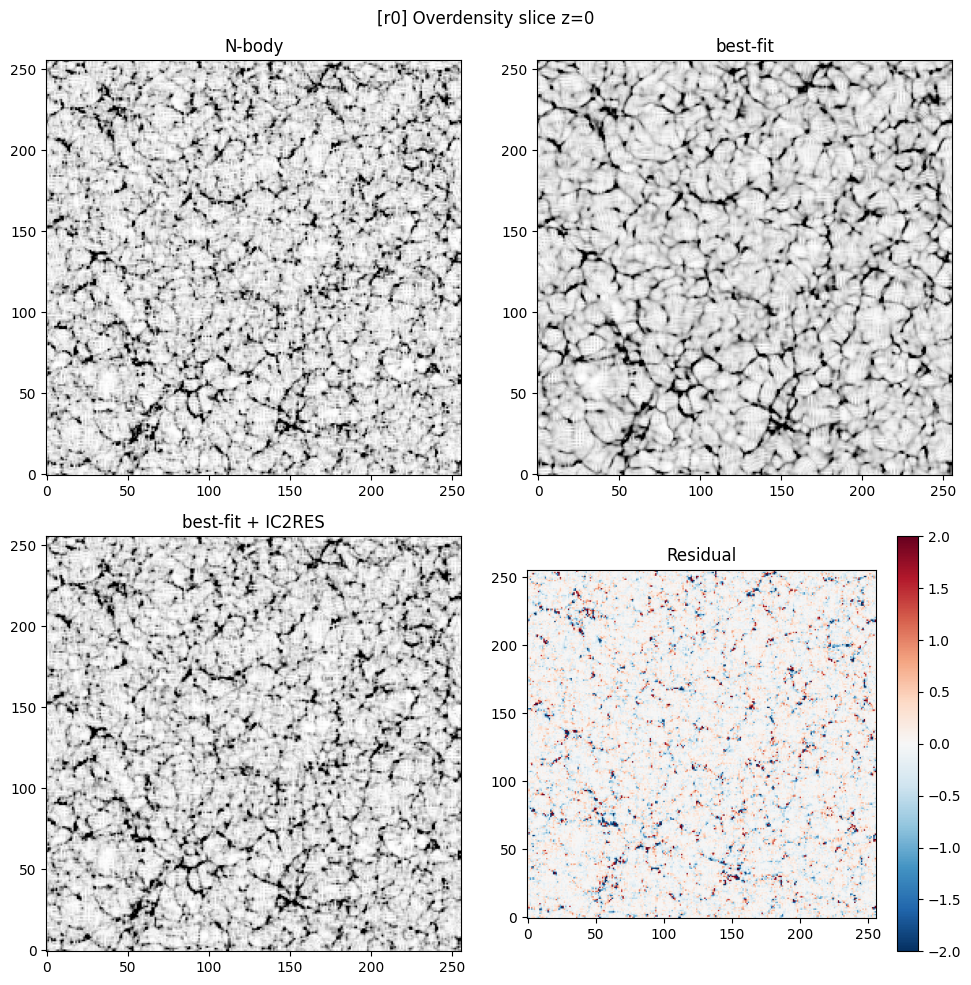

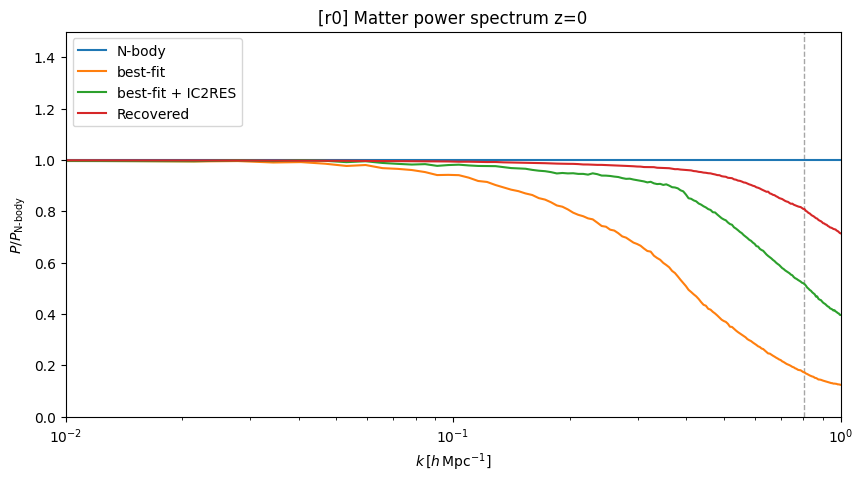

[r0] best-fit χ² (k≤0.3) = 3.097623e-02
[r0] best-fit + IC2RES χ² (k≤0.3) = 1.930982e-03
[r0] Recovered χ² (k≤0.3) = 2.007697e-04


In [13]:
k_cut = 0.061   # h/Mpc — matches the tophat0.4 best-fit filter
k_width = 0.01

residual_pred   = apply_unet_to_field(init_delta, loaded_model,
                                      infer_patch_size, infer_padding, infer_overlap, device)
residual_pred   = highpass_field(residual_pred, k_cut, boxsize, width=k_width)
final_psi_div   = best_fit_psi_div + residual_pred

delta_nbody     = target_delta
delta_bestfit   = best_fit_delta
delta_final     = psi_div_to_delta(final_psi_div,  dl, snapshot_info[0]['pos'],
                                    veck_main, N_p, boxsize, MAS)
delta_recovered = psi_div_to_delta(target_psi_div, dl, snapshot_info[0]['pos'],
                                    veck_main, N_p, boxsize, MAS)
delta_residual  = delta_nbody - delta_final

labels = ['N-body', 'best-fit', 'best-fit + IC2RES', 'Recovered']
deltas = [delta_nbody, delta_bestfit, delta_final, delta_recovered]

# Overdensity slices (Residual replaces Recovered)
slice_labels = ['N-body', 'best-fit', 'best-fit + IC2RES', 'Residual']
slice_deltas = [delta_nbody, delta_bestfit, delta_final, delta_residual]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, d, lab in zip(axes.flat, slice_deltas, slice_labels):
    img = np.mean(d[:1], axis=0).T
    if lab == 'Residual':
        im = ax.imshow(img, cmap='RdBu_r', vmin=-2, vmax=2, origin='lower')
        plt.colorbar(im, ax=ax)
    else:
        ax.imshow(img, cmap='gray_r', vmin=-1, vmax=3, origin='lower')
    ax.set_title(lab)
plt.suptitle(f'[r{realization}] Overdensity slice z=0')
plt.tight_layout(); plt.show()

# Power spectra
Pks = [PKL.Pk(d, boxsize, axis=0, MAS=MAS, threads=threads, verbose=False) for d in deltas]

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xscale('log')
ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P/P_{\rm N\text{-}body}$')
ax.set_xlim(0.01, 1.0); ax.set_ylim(0, 1.5)
ax.axvline(veck_main.Nyquist_freq, color='grey', ls='--', lw=1, alpha=0.7)
for pk, lab in zip(Pks, labels):
    ax.plot(Pks[0].k3D, pk.Pk[:, 0] / Pks[0].Pk[:, 0], label=lab)
ax.legend(); plt.title(f'[r{realization}] Matter power spectrum z=0'); plt.show()

# # Bispectrum
# k1, k2 = 0.2, 0.2
# theta   = np.linspace(0, np.pi, 25)
# Bks = [PKL.Bk(d, boxsize, k1, k2, theta, MAS=MAS, threads=8) for d in deltas]

# fig, ax = plt.subplots(figsize=(10, 5))
# ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$B/B_{\rm N\text{-}body}$')
# ax.set_xlim(0, np.pi); ax.set_ylim(0, 1.5)
# ax.set_title(f'[r{realization}] Bispectrum z=0, k1={k1}, k2={k2}')
# for bk, lab in zip(Bks, labels):
#     ax.plot(theta, bk.B / Bks[0].B, label=lab)
# ax.legend(); plt.show()

# χ² vs N-body (k ≤ 0.3)
mask_k = Pks[0].k3D <= 0.3
for pk, lab in zip(Pks[1:], labels[1:]):
    ratio = pk.Pk[:, 0] / Pks[0].Pk[:, 0]
    print(f'[r{realization}] {lab} χ² (k≤0.3) = {np.mean((ratio[mask_k] - 1)**2):.6e}')

## 4. Generalization Test (realization 1)

Reading snapshot...


Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading best-fit psi_div from /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4v1/best-fitL1N256-18.npz


apply_unet (z-slices): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:06<00:00,  2.11it/s]


apply_unet done: step=20, elapsed=6.2s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


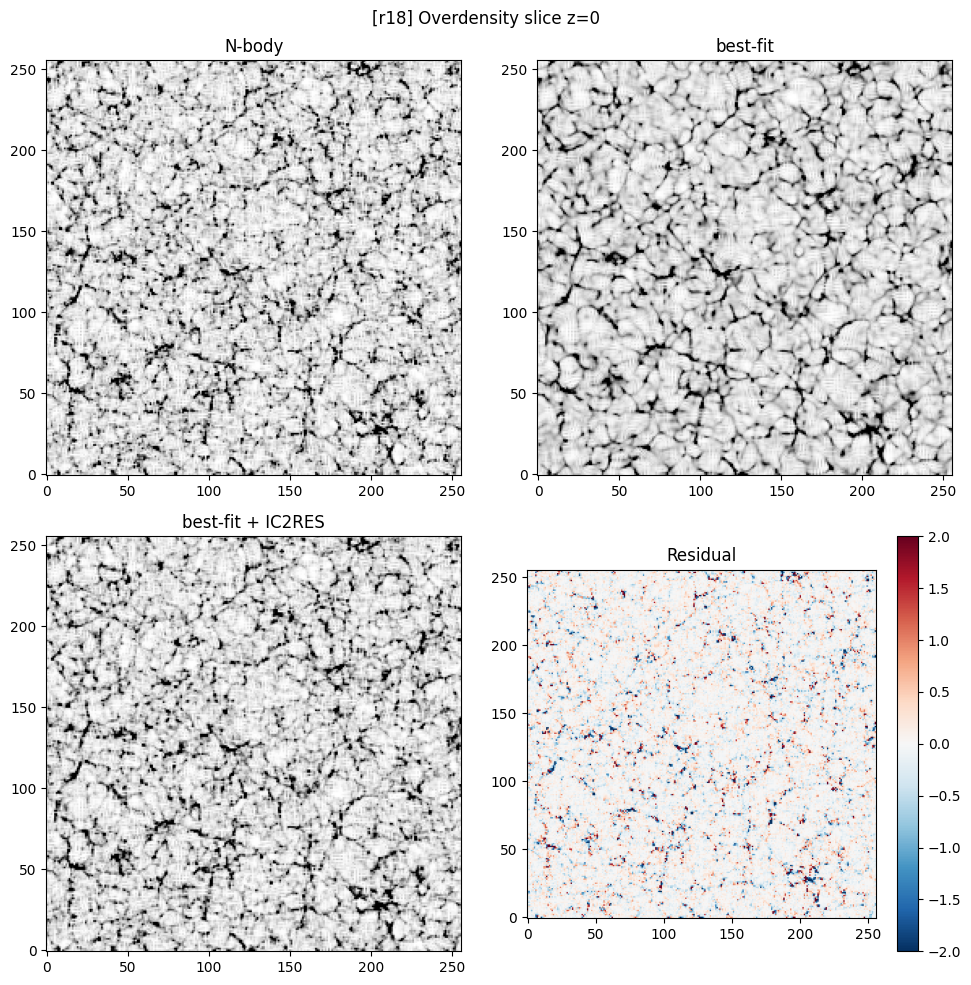

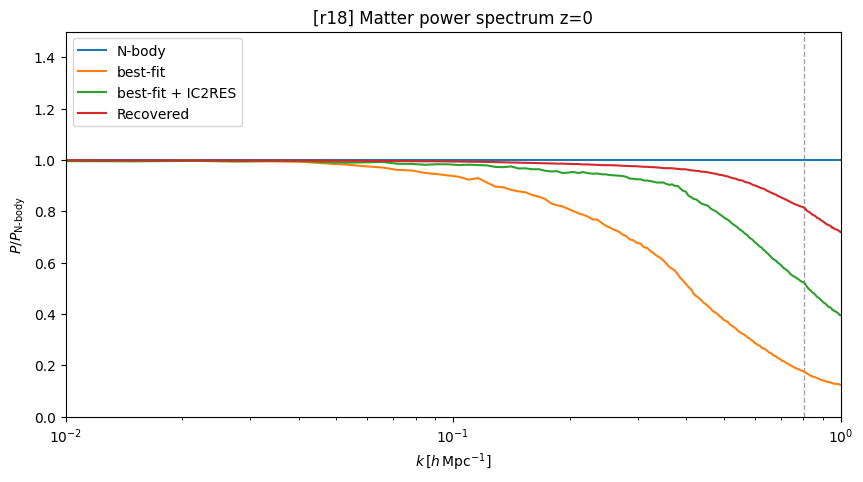


Computing bispectrum of the field...
Time to compute bispectrum = 6.70

Computing bispectrum of the field...
Time to compute bispectrum = 6.72

Computing bispectrum of the field...
Time to compute bispectrum = 6.99

Computing bispectrum of the field...
Time to compute bispectrum = 6.89


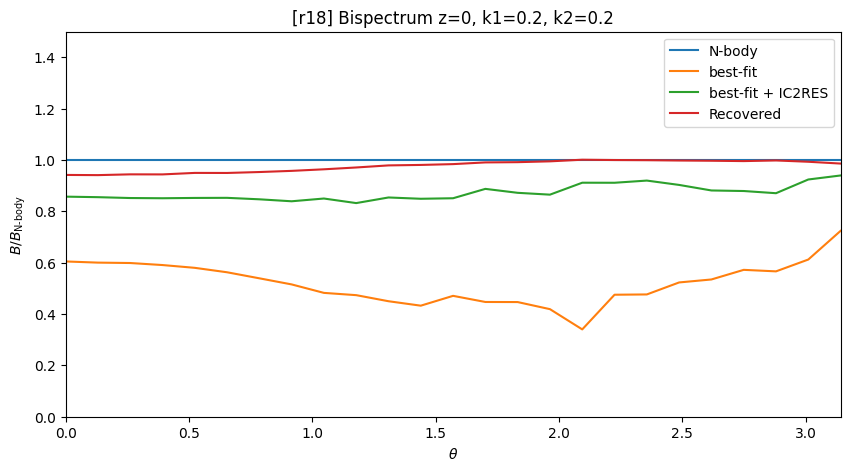

[r18] best-fit χ² (k≤0.3) = 2.981166e-02
[r18] best-fit + IC2RES χ² (k≤0.3) = 1.687507e-03
[r18] Recovered χ² (k≤0.3) = 1.995481e-04


In [14]:
realization_test = 18

snapshot_info_test = load_snapshot_pair(
    dl,
    cfg.snapshot_paths(realization_test, N_p),
    cfg.snapshot_format(N_p),
    boxsize, grid_size,
)

init_delta_test     = snapshot_info_test[0]['delta']
target_psi_div_test = compute_target_psi_div(dl, snapshot_info_test, N_p, boxsize, veck_main)

best_fit_psi_div_test, best_fit_delta_test, target_delta_test = compute_best_fit(
    dl, init_delta_test, target_psi_div_test,
    snapshot_info_test[0]['pos'], snapshot_info_test[1]['delta'],
    veck_main, N_p, boxsize, MAS,
    realization_test, filter_dir, L,
    coef_file=coef_file,
    overwrite=False,
)

residual_pred_test  = apply_unet_to_field(
    init_delta_test, loaded_model, infer_patch_size, infer_padding, infer_overlap, device)
residual_pred_test  = highpass_field(residual_pred_test, k_cut, boxsize)
delta_final_test    = psi_div_to_delta(
    best_fit_psi_div_test + residual_pred_test,
    dl, snapshot_info_test[0]['pos'], veck_main, N_p, boxsize, MAS)
delta_recovered_test = psi_div_to_delta(
    target_psi_div_test, dl, snapshot_info_test[0]['pos'], veck_main, N_p, boxsize, MAS)
delta_residual_test  = target_delta_test - delta_final_test

labels_t = ['N-body', 'best-fit', 'best-fit + IC2RES', 'Recovered']
deltas_t = [target_delta_test, best_fit_delta_test, delta_final_test, delta_recovered_test]

# Overdensity slices (Residual replaces Recovered)
slice_labels_t = ['N-body', 'best-fit', 'best-fit + IC2RES', 'Residual']
slice_deltas_t = [target_delta_test, best_fit_delta_test, delta_final_test, delta_residual_test]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, d, lab in zip(axes.flat, slice_deltas_t, slice_labels_t):
    img = np.mean(d[:1], axis=0).T
    if lab == 'Residual':
        im = ax.imshow(img, cmap='RdBu_r', vmin=-2, vmax=2, origin='lower')
        plt.colorbar(im, ax=ax)
    else:
        ax.imshow(img, cmap='gray_r', vmin=-1, vmax=3, origin='lower')
    ax.set_title(lab)
plt.suptitle(f'[r{realization_test}] Overdensity slice z=0')
plt.tight_layout(); plt.show()

# Power spectra
Pks_t = [PKL.Pk(d, boxsize, axis=0, MAS=MAS, threads=threads, verbose=False) for d in deltas_t]

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xscale('log')
ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P/P_{\rm N\text{-}body}$')
ax.set_xlim(0.01, 1.0); ax.set_ylim(0, 1.5)
ax.axvline(veck_main.Nyquist_freq, color='grey', ls='--', lw=1, alpha=0.7)
for pk, lab in zip(Pks_t, labels_t):
    ax.plot(Pks_t[0].k3D, pk.Pk[:, 0] / Pks_t[0].Pk[:, 0], label=lab)
ax.legend(); plt.title(f'[r{realization_test}] Matter power spectrum z=0'); plt.show()

# Bispectrum
k1, k2 = 0.2, 0.2
theta   = np.linspace(0, np.pi, 25)
Bks_t = [PKL.Bk(d, boxsize, k1, k2, theta, MAS=MAS, threads=8) for d in deltas_t]

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$B/B_{\rm N\text{-}body}$')
ax.set_xlim(0, np.pi); ax.set_ylim(0, 1.5)
ax.set_title(f'[r{realization_test}] Bispectrum z=0, k1={k1}, k2={k2}')
for bk, lab in zip(Bks_t, labels_t):
    ax.plot(theta, bk.B / Bks_t[0].B, label=lab)
ax.legend(); plt.show()

# χ²
mask_k = Pks_t[0].k3D <= 0.3
for pk, lab in zip(Pks_t[1:], labels_t[1:]):
    ratio = pk.Pk[:, 0] / Pks_t[0].Pk[:, 0]
    print(f'[r{realization_test}] {lab} χ² (k≤0.3) = {np.mean((ratio[mask_k] - 1)**2):.6e}')